# EXPLORATORY DATA ANALYSIS ON A DATASET:

### Objective:

The main goal of this assignment is to conduct a thorough exploratory analysis of the 
"cardiographic.csv" dataset to uncover insights, identify patterns, and understand the dataset's 
underlying structure. You will use statistical summaries, visualizations, and data manipulation 
techniques to explore the dataset comprehensively

# Tasks:

### 1. Data Cleaning and Preparation:

● Load the dataset into a data frame or equivalent data structure.
● Handle missing values appropriately (e.g., imputation, deletion).
● Identify and correct any inconsistencies in data types (e.g., numerical values stored 
as strings).
● Detect and treat outliers if necessary

In [30]:
# Import
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings . filterwarnings("ignore")

In [31]:
# Load the dataset
df = pd.read_csv("Cardiotocographic.csv")

In [32]:
# Top five columns
df.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


In [33]:
# shape of the dataset
df.shape

(2126, 14)

In [34]:
# shape of the size
df.size

29764

In [35]:
# Missing values analysis
missing = pd.DataFrame({'Missing' : df.isnull().sum(),
                        'Percentage' : (df.isnull().sum()/len(df) * 100)
                       })
missing . sort_values('Percentage',ascending = False)

,Missing,Percentage
LB,21,0.987770
DS,21,0.987770
DP,21,0.987770
MLTV,21,0.987770
Width,21,0.987770
Tendency,21,0.987770
NSP,21,0.987770
AC,20,0.940734
FM,0,0.000000
UC,0,0.000000


In [36]:
# Total Null Percentage 
total_null_percentage = (df.isnull().sum().sum() / df.size) * 100
print(f"Total Null Percentage: {total_null_percentage:.2f}%")

Total Null Percentage: 0.56%


In [37]:
# Check the dtypes of columns
df.dtypes

LB          float64
AC          float64
FM          float64
UC          float64
DL          float64
DS          float64
DP          float64
ASTV        float64
MSTV        float64
ALTV        float64
MLTV        float64
Width       float64
Tendency    float64
NSP         float64
dtype: object

In [38]:
# Handle missing value 
for col in df.select_dtypes(include = ['int','float']).columns:
    df[col] = df[col].fillna(df[col].median())

In [39]:
# verify
df.isnull().sum().sum()

np.int64(0)

In [40]:
# Check dublicate values
df.duplicated().sum()

np.int64(2)

In [41]:
#Drop the duplicates
df=df.drop_duplicates()

In [42]:
#verify
df.duplicated().sum()

np.int64(0)

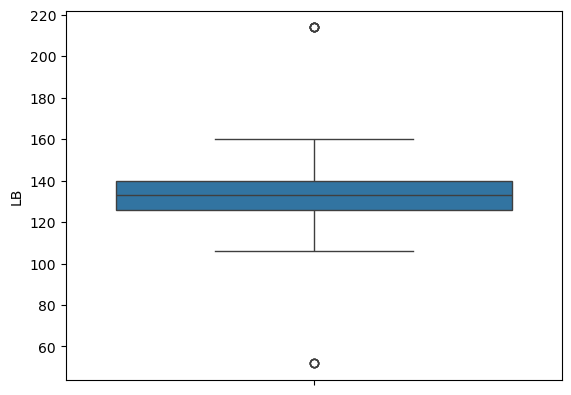

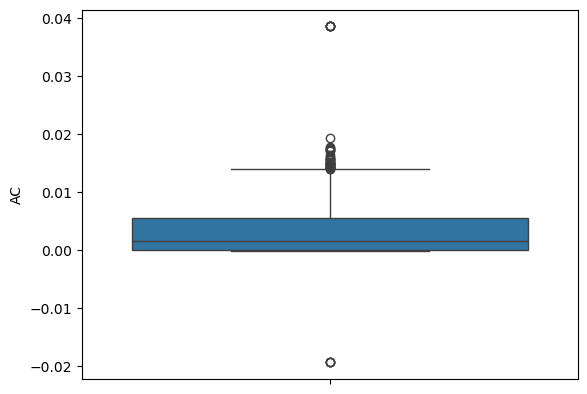

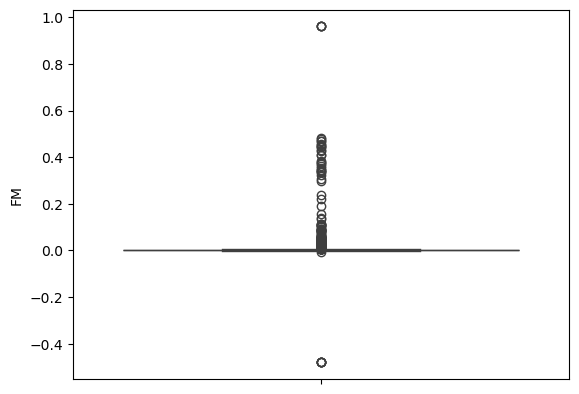

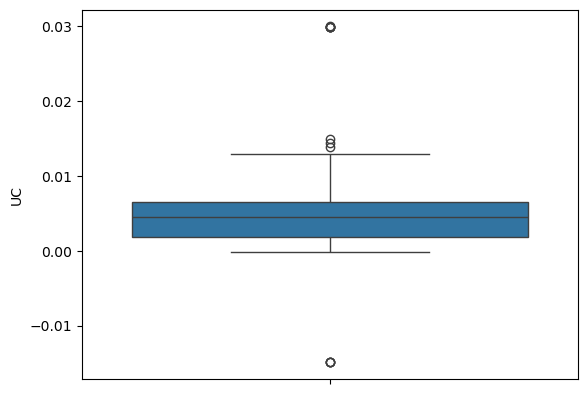

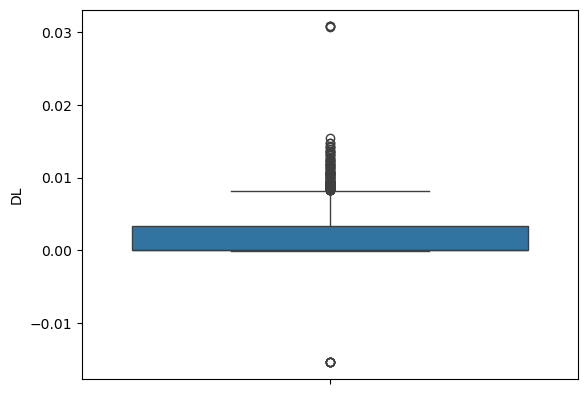

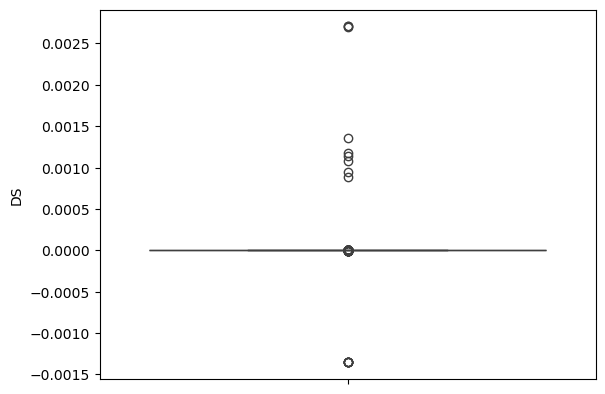

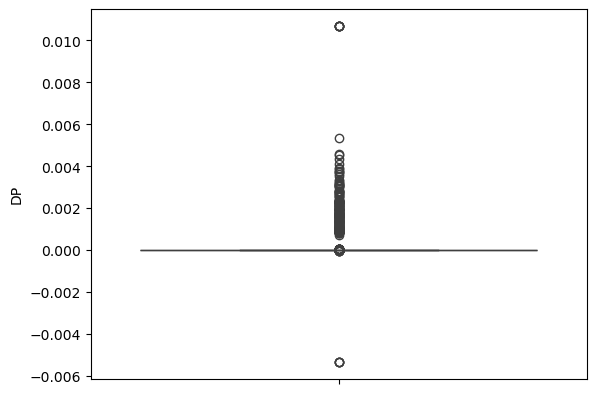

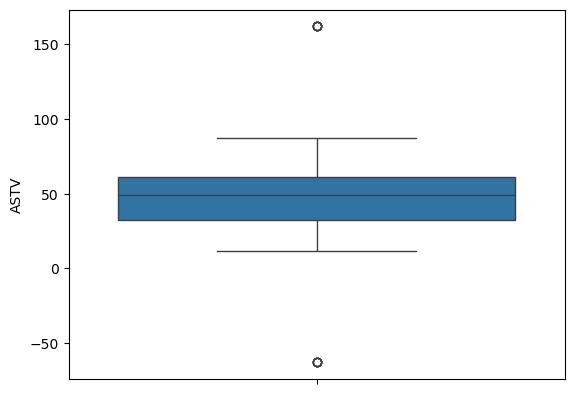

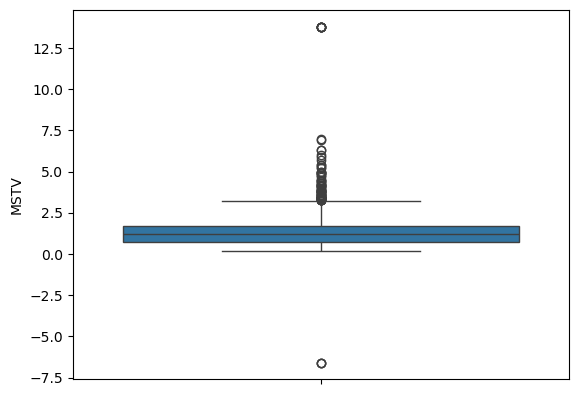

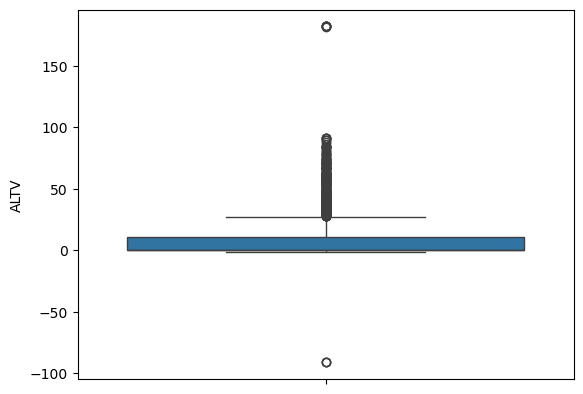

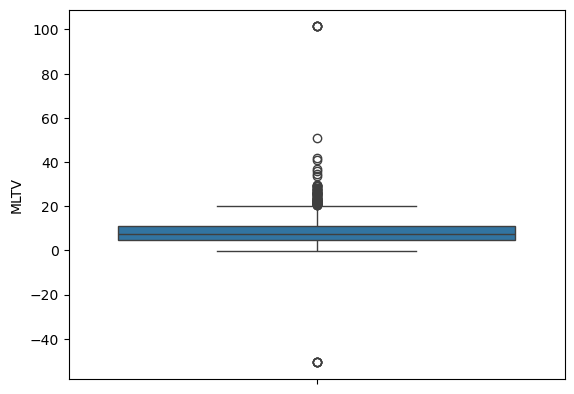

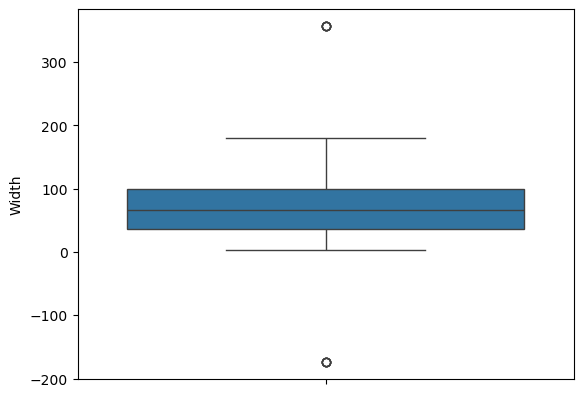

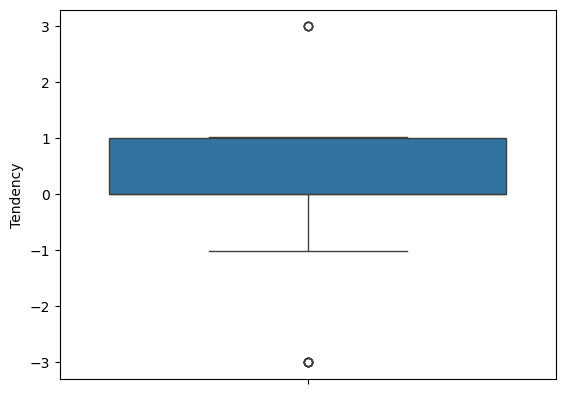

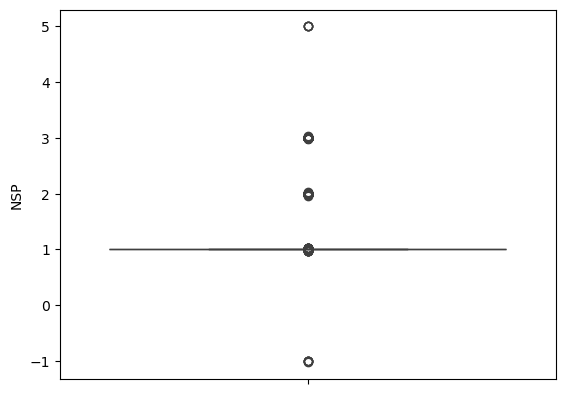

In [43]:
# ouitlier checking
for col in df.select_dtypes(include = ['int','float']).columns:
    sns.boxplot(df[col])
    plt.show()

In [44]:
# Handle outliers
for col in df.select_dtypes(include = ['int','float']).columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    IQR = q3-q1
    lower_bound = q1 - 1.5*IQR
    upper_bound = q3 + 1.5* IQR
    df[col] = df[col].clip(lower_bound,upper_bound)

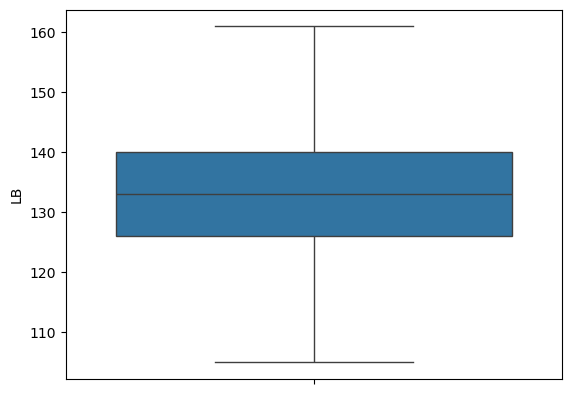

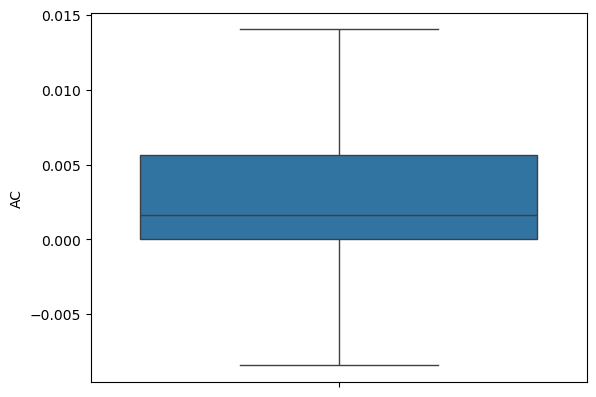

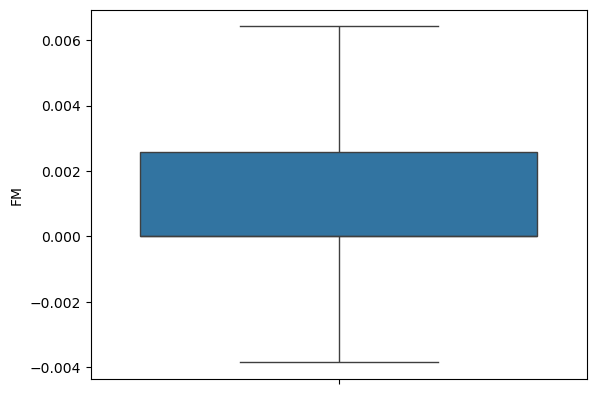

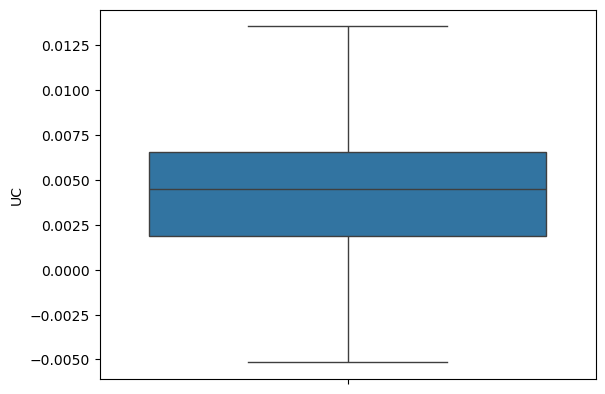

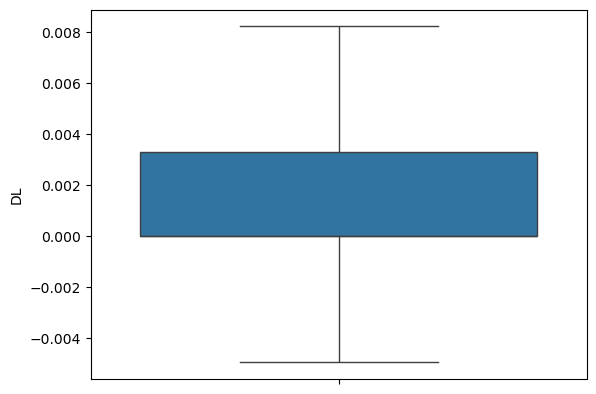

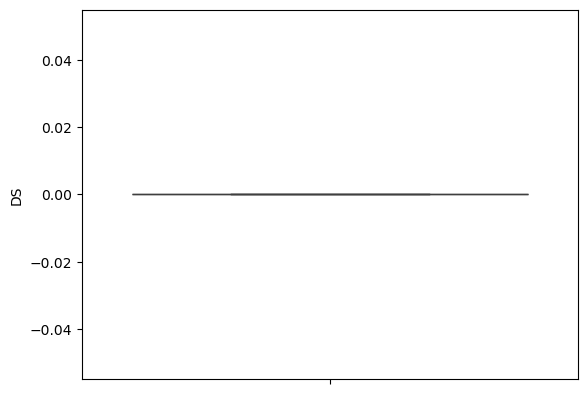

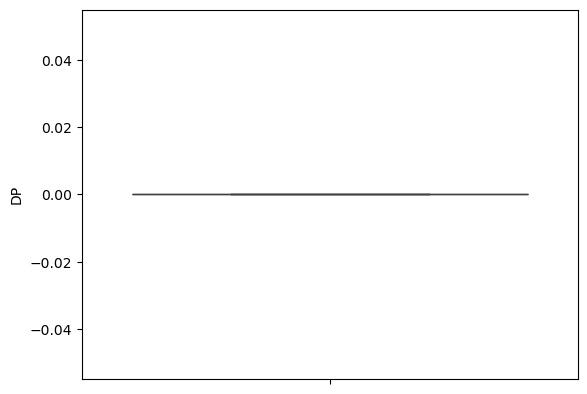

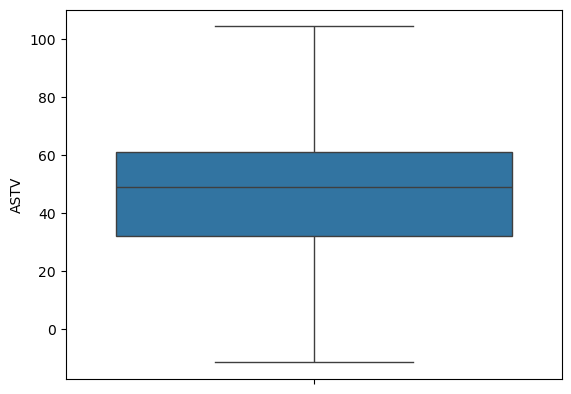

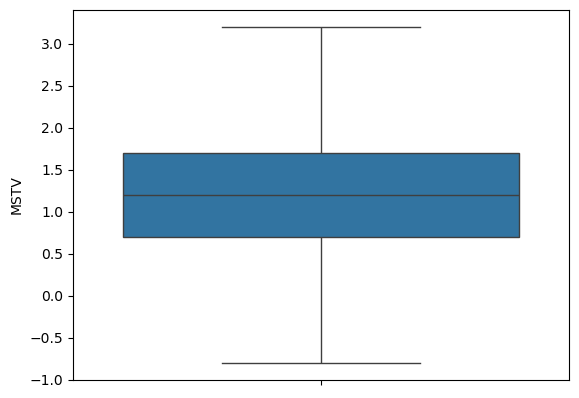

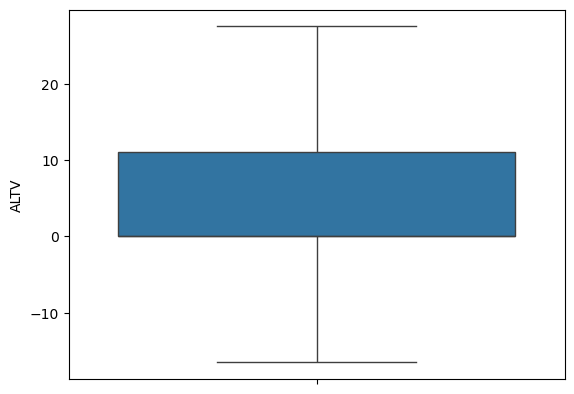

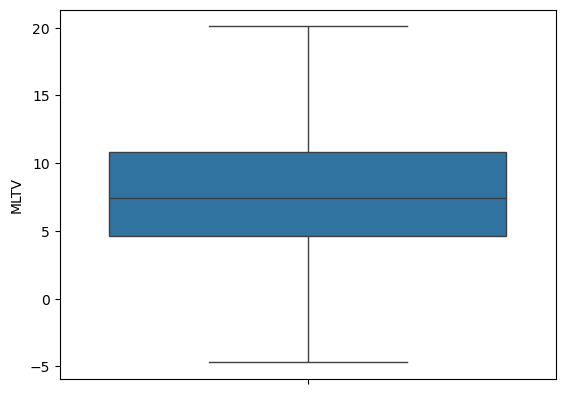

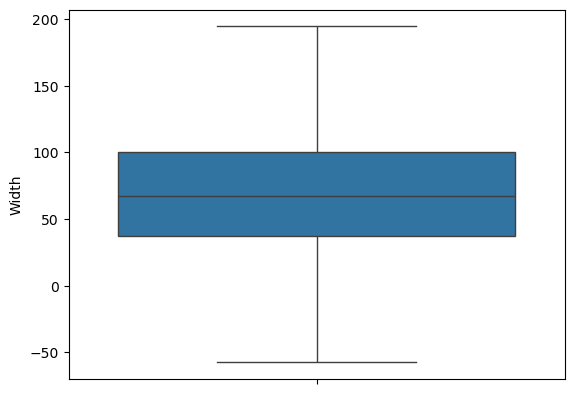

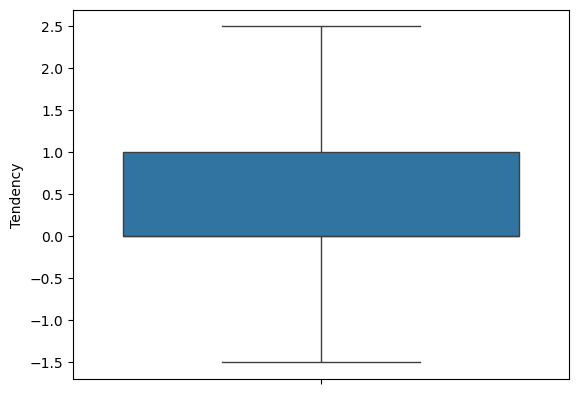

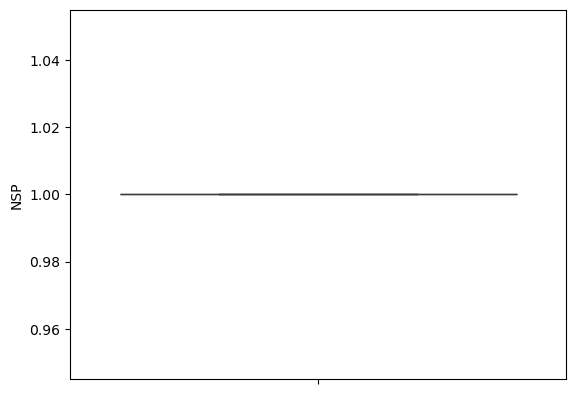

In [45]:
#verify
for col in df.select_dtypes(include = ['int','float']).columns:
    sns.boxplot(df[col])
    plt.show()

# 2. Statistical Summary:

● Provide a statistical summary for each variable in the dataset, including measures of 
central tendency (mean, median) and dispersion (standard deviation, interquartile 
range).
● Highlight any interesting findings from this summary

In [46]:
# General Information
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2124 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2124 non-null   float64
 1   AC        2124 non-null   float64
 2   FM        2124 non-null   float64
 3   UC        2124 non-null   float64
 4   DL        2124 non-null   float64
 5   DS        2124 non-null   float64
 6   DP        2124 non-null   float64
 7   ASTV      2124 non-null   float64
 8   MSTV      2124 non-null   float64
 9   ALTV      2124 non-null   float64
 10  MLTV      2124 non-null   float64
 11  Width     2124 non-null   float64
 12  Tendency  2124 non-null   float64
 13  NSP       2124 non-null   float64
dtypes: float64(14)
memory usage: 248.9 KB


In [47]:
# Statistical Summary
df.describe()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2124.000000,2124.000000,2124.000000,2124.000000,2124.000000,2124.0,2124.0,2124.000000,2124.000000,2124.000000,2124.000000,2124.000000,2124.000000,2124.0
mean,133.288721,0.003133,0.001570,0.004365,0.001772,0.0,0.0,46.998334,1.304554,6.697979,8.002912,70.318547,0.316835,1.0
std,9.926790,0.003830,0.002487,0.003001,0.002670,0.0,0.0,17.609911,0.781303,10.381254,5.046792,39.577385,0.622623,0.0
min,105.000000,-0.008418,-0.003853,-0.005158,-0.004938,0.0,0.0,-11.500000,-0.800000,-16.500000,-4.700000,-57.500000,-1.500000,1.0
25%,126.000000,0.000000,0.000000,0.001858,0.000000,0.0,0.0,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.0
50%,133.000000,0.001634,0.000000,0.004486,0.000000,0.0,0.0,49.000000,1.200000,0.000000,7.400000,67.000000,0.000000,1.0
75%,140.000000,0.005612,0.002568,0.006536,0.003292,0.0,0.0,61.000000,1.700000,11.000000,10.800000,100.000000,1.000000,1.0
max,161.000000,0.014030,0.006421,0.013552,0.008230,0.0,0.0,104.500000,3.200000,27.500000,20.100000,194.500000,2.500000,1.0


## Interpretation of this statistics:

### 1. LB :

1. Total count (2124) , so there is no any missing value.
2. Mean (133.288721 ) , IQR(133.288721) Both are approximately same so this is noramally distributed

### 2. AC


Mean: 0.00313
Median: 0.00163
Standard Deviation: 0.00383
Range: -0.00842 to 0.01403

The average acceleration value is close to zero.
The mean is slightly larger than the median, suggesting a slight positive skew.
The low standard deviation indicates that most values are concentrated near the mean.

### 3. FM (Fetal Movements)

Mean: 0.00157
Median: 0
Standard Deviation: 0.00249

Most fetal movement values are zero since the median is 0.
The mean is slightly positive because a few observations contain higher movement values.
This indicates a positively skewed distribution.

### 4. UC (Uterine Contractions)

Mean: 0.00437
Median: 0.00449
Standard Deviation: 0.00300

The mean and median are almost identical, indicating a fairly symmetric distribution.
The variation among observations is relatively low.

### 5. DL (Light Decelerations)

Mean: 0.00177
Median: 0
Standard Deviation: 0.00267

Most observations have no light decelerations (median = 0).
A few larger values increase the mean, indicating positive skewness.

### 6. DS (Severe Decelerations)

Mean: 0
Standard Deviation: 0
Minimum = Maximum = 0

Every observation has the same value (0).
This feature has zero variance and provides no useful information for predictive modeling.
It can be safely removed before model training.

### 7. DP (Prolonged Decelerations)

Mean: 0
Standard Deviation: 0
Minimum = Maximum = 0
Similar to DS, this feature contains only zeros.
Since it has no variation, it is not informative and may be dropped.

### 8. ASTV (Percentage of Time with Abnormal Short-TermVariability)

Mean: 46.998
Median: 49
Standard Deviation: 17.61
Range: -11.5 to 104.5

The average abnormal short-term variability is approximately 47%. The large standard deviation suggests considerable variability among observations.
The minimum and maximum values appear unusual and should be checked for potential data quality issues or outliers.

### 9. MSTV (Mean Short-Term Variability)

Mean: 1.305
Median: 1.2
Standard Deviation: 0.781

The average short-term variability is approximately 1.3.
Mean and median are close, suggesting a roughly symmetric distribution.
The spread of the data is moderate.

### 10. ALTV (Percentage of Time with Abnormal Long-Term Variability)

Mean: 6.70
Median: 0
Standard Deviation: 10.38

Since the median is 0 while the mean is 6.7, many observations are zero with a few high values.
This indicates a highly positively skewed distribution.

### 11. MLTV (Mean Long-Term Variability)

Mean: 8.00
Median: 7.4
Standard Deviation: 5.05

The average long-term variability is about 8.
The mean and median are fairly close, indicating a relatively balanced distribution.
Moderate variability exists among observations.

### 12. Width

Mean: 70.32
Median: 67
Standard Deviation: 39.58
Range: -57.5 to 194.5

The average histogram width is approximately 70.
The large standard deviation indicates high variability.
Negative values may indicate data quality issues and should be verified.

### 13. Tendency

Mean: 0.317
Median: 0
Standard Deviation: 0.623

Most observations have a tendency value of 0.
The positive mean suggests that some observations have higher tendency values.
The distribution is positively skewed.

### 14. NSP (Target Variable)

Mean: 1
Standard Deviation: 0
Minimum = Maximum = 1

Every observation belongs to class 1.
The target variable has no class variation, which is unusual for a classification problem.
This may indicate:
only one class was selected during preprocessing,
incorrect filtering,
or an issue while loading the dataset.

# 3. Data Visualization:

● Create histograms or boxplots to visualize the distributions of various numerical variables.
● Use bar charts or pie charts to display the frequency of categories for categorical variables.
● Generate scatter plots or correlation heatmaps to explore relationships between pairs of variables.
● Employ advanced visualization techniques like pair plots, or violin plots for deeper insights.

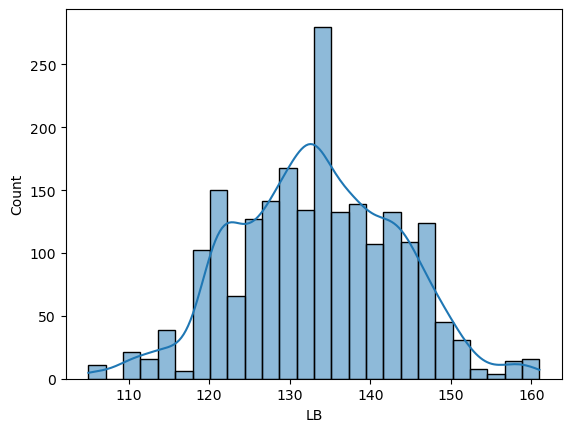

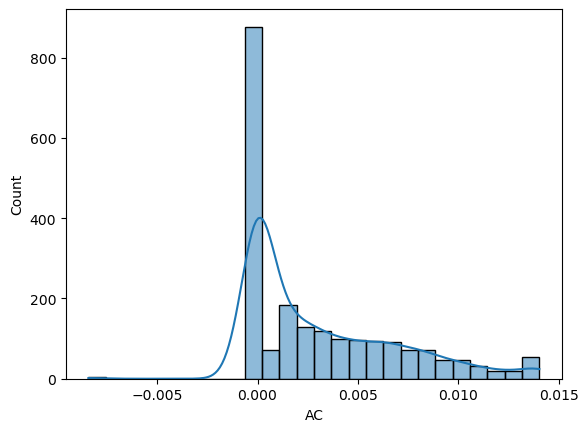

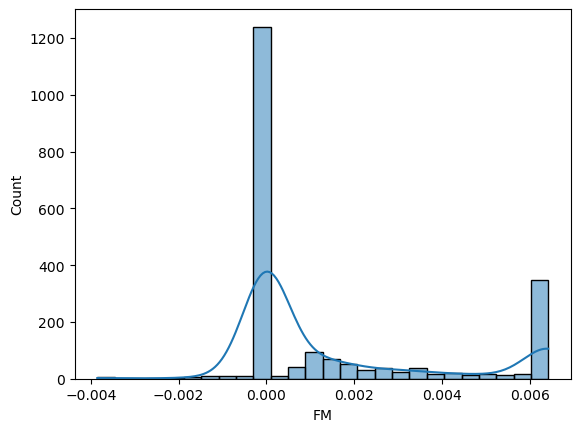

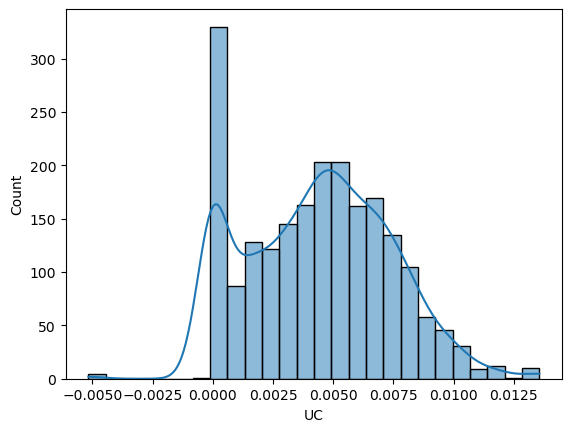

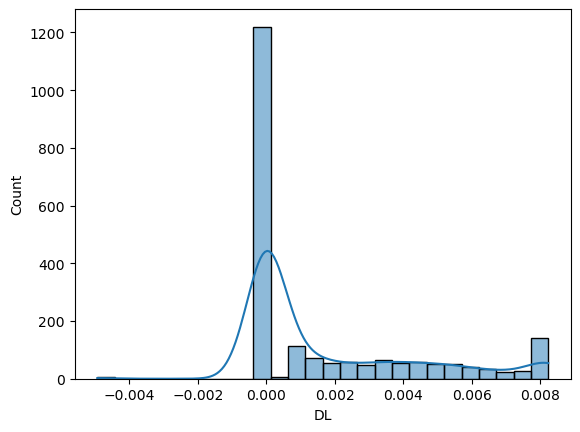

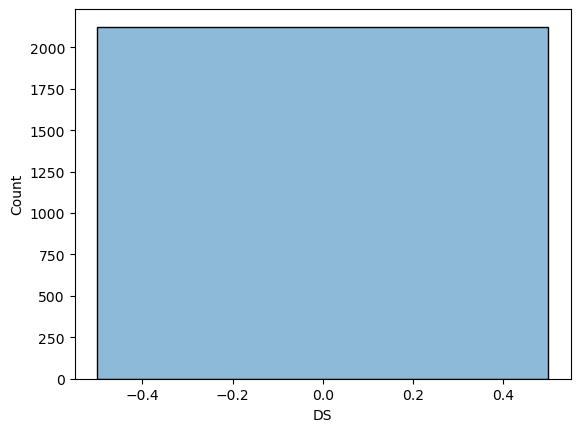

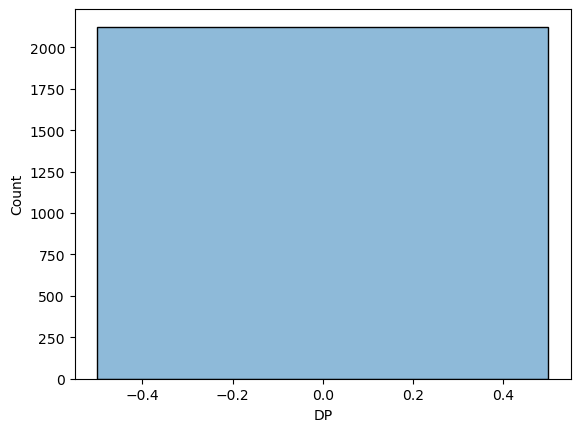

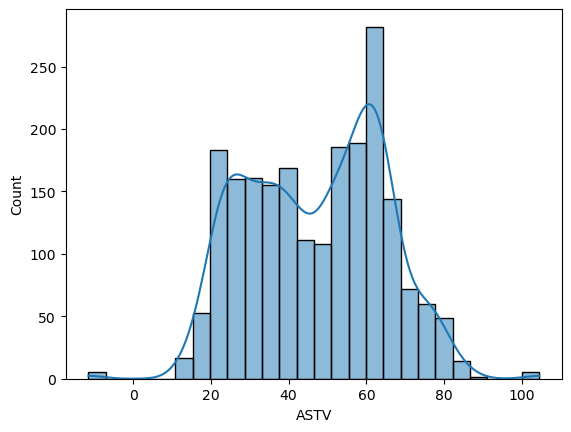

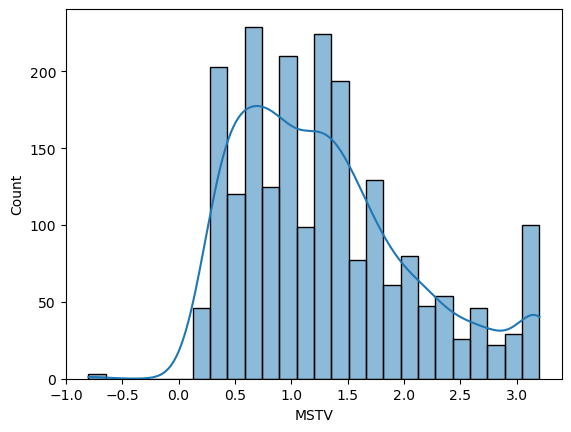

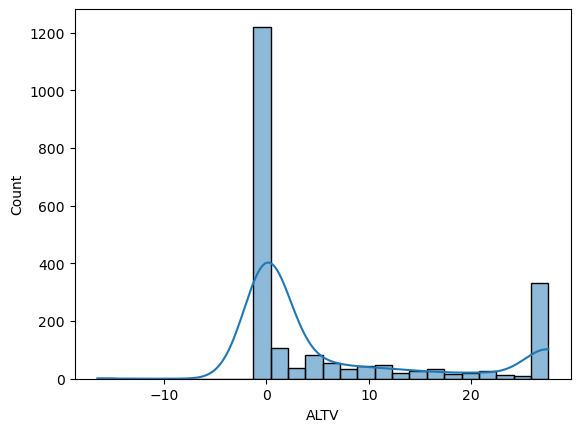

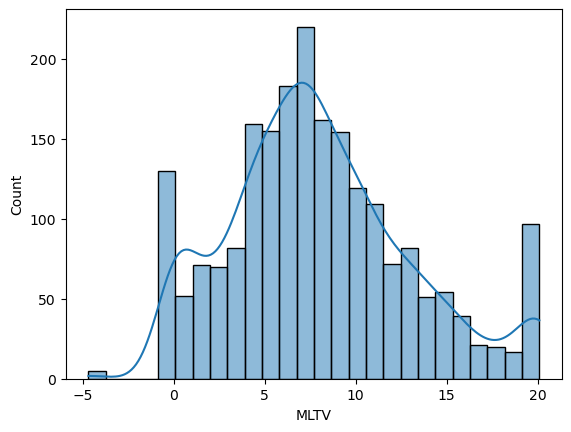

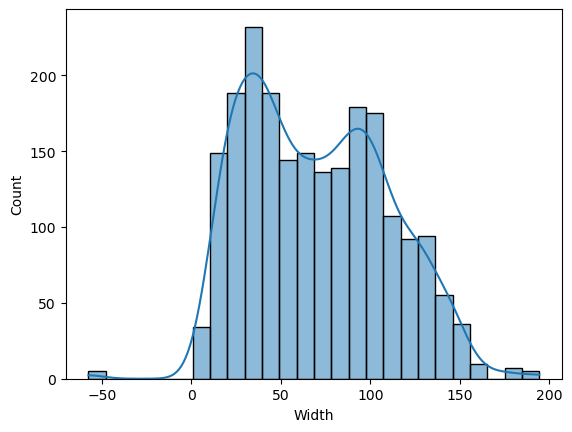

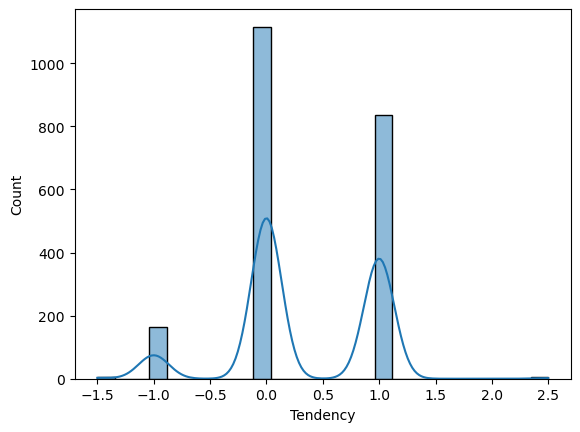

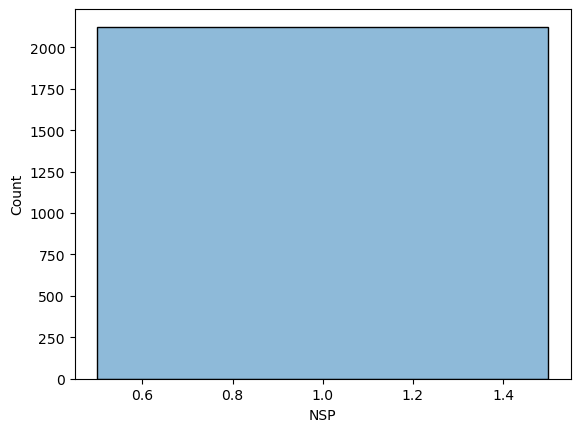

In [48]:
# Histogram for Numerical columns
for col in df.select_dtypes (include = ['int','float']).columns:
    sns.histplot(df[col], kde = True)
    plt.show()

In [49]:
# To extract categorical columns 
cat_cols = df.select_dtypes(include = 'object').columns
print(cat_cols)

Index([], dtype='object')


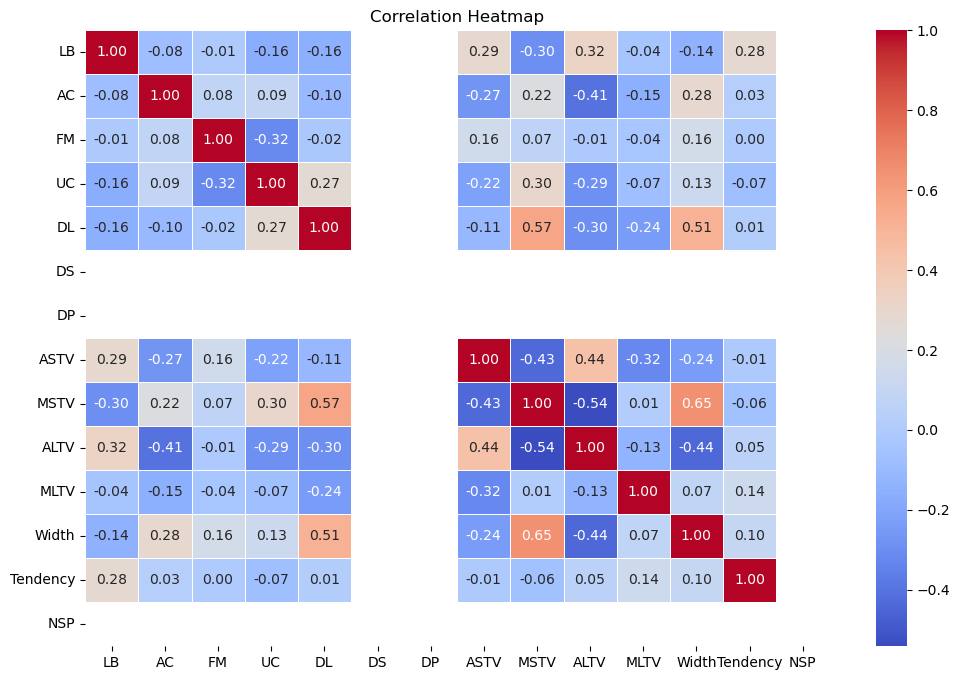

In [50]:
# Compute correlation matrix
corr = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f",
            linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

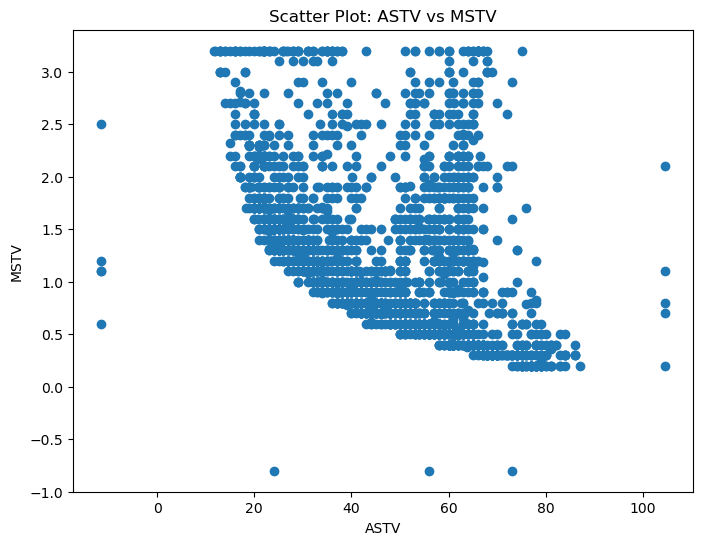

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(df["ASTV"], df["MSTV"])

plt.title("Scatter Plot: ASTV vs MSTV")
plt.xlabel("ASTV")
plt.ylabel("MSTV")

plt.show()

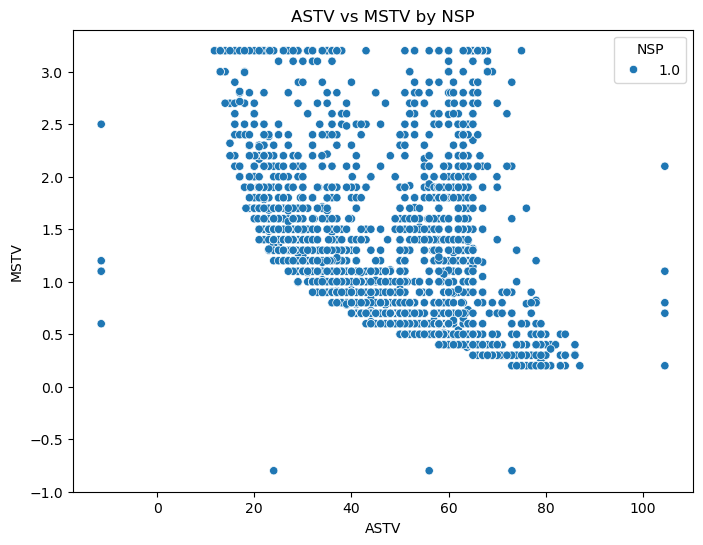

In [52]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="ASTV",
    y="MSTV",
    hue="NSP"
)

plt.title("ASTV vs MSTV by NSP")
plt.show()

In [53]:
num_cols = df.select_dtypes(include = ['int','float']).columns
print(num_cols)

Index(['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV',
       'MLTV', 'Width', 'Tendency', 'NSP'],
      dtype='object')


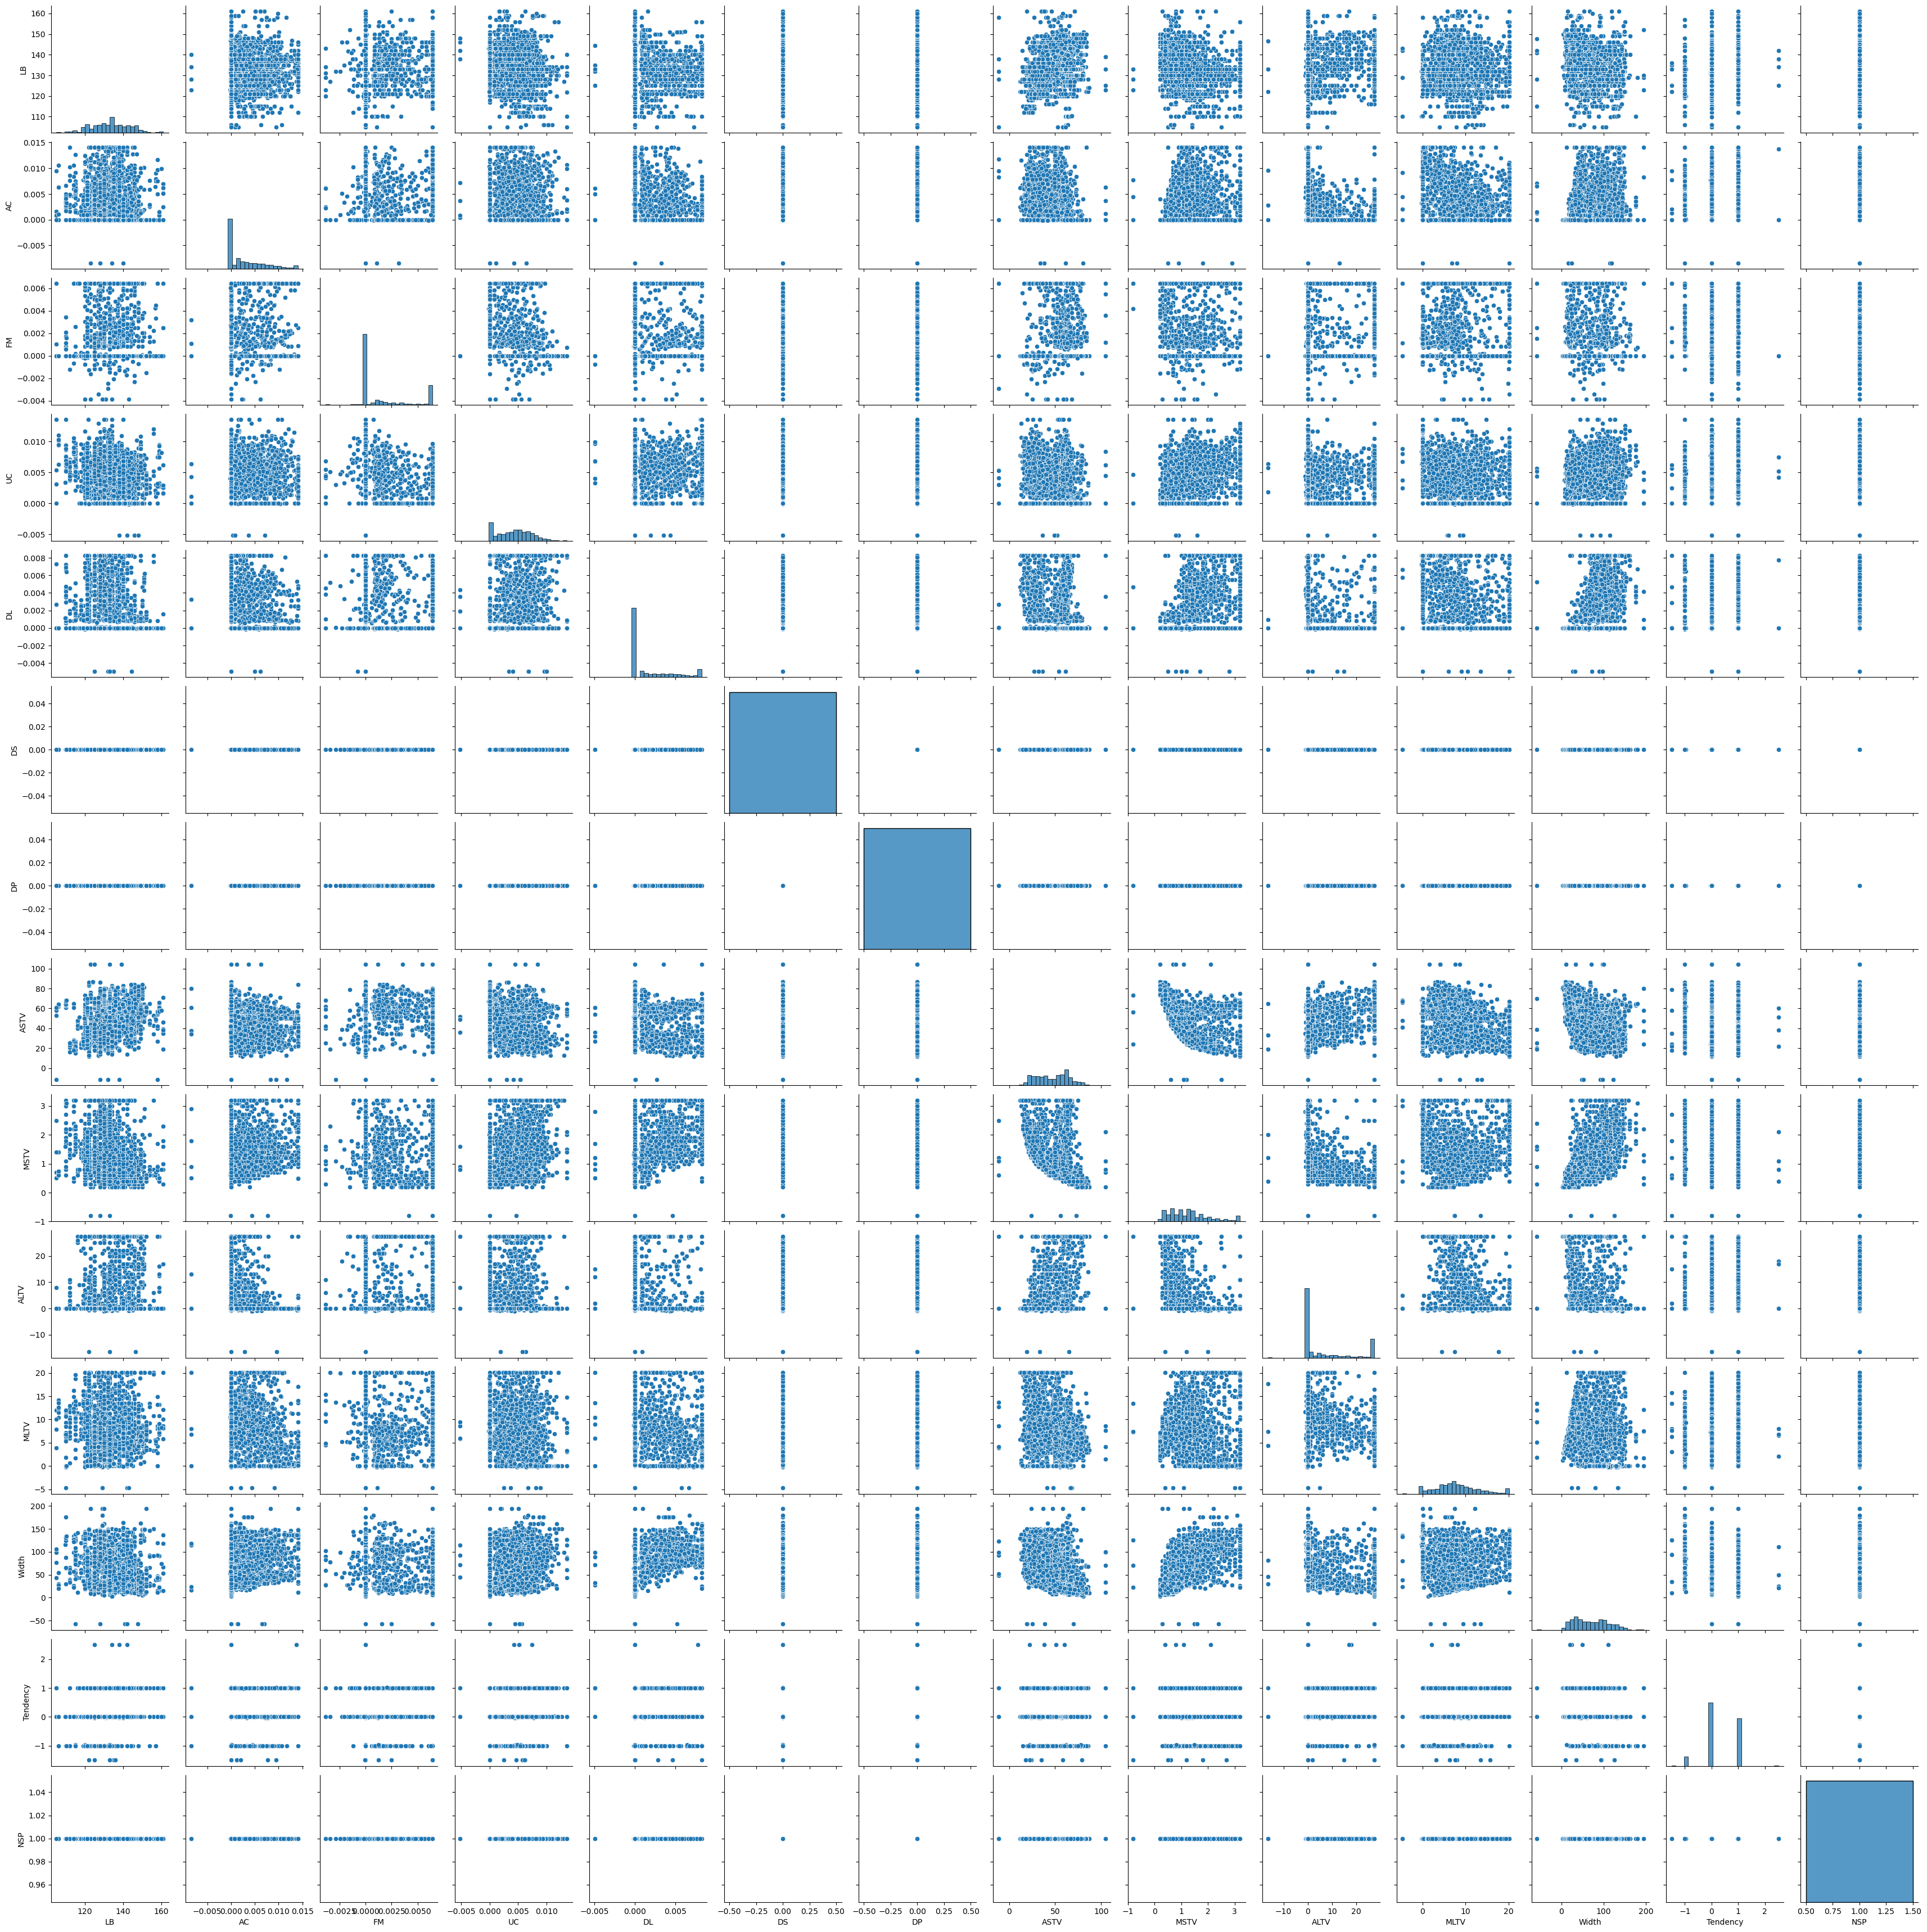

In [54]:
sns.pairplot(df[num_cols])

# 4. Pattern Recognition and Insights:

● Identify any correlations between variables and discuss their potential implications.

### 1. Strong Positive Correlations (≥ 0.5)

# Variables	 # Correlation 	# Interpretation

MSTV ↔ Width 	0.65	Strong positive relationship. As MSTV increases, Width tends to increase.
DL ↔ MSTV	0.57	Moderate to strong positive correlation.
DL ↔ Width	0.51	Moderate positive correlation.

# 2. Moderate Negative Correlations

In [55]:
# Variables	# Correlation	# Interpretation

# MSTV ↔ ALTV	# -0.54	  Strong inverse relationship.
# ASTV ↔ MSTV	# -0.43 	Moderate negative correlation.
# ALTV ↔ Width	#-0.44	 Moderate negative correlation.
# AC ↔ ALTV	# -0.41	 Moderate negative correlation.


# 3. Weak Correlations

Most remaining variables have correlations between -0.3 and +0.3, for example:
LB ↔ AC = -0.08
FM ↔ Width = 0.16
UC ↔ Tendency = -0.07
MLTV ↔ Tendency = 0.14
Implication:
These variables have weak linear relationships and are relatively independent of each other.

# 4. No Perfect Correlation

There are no correlations close to +1 or -1 (excluding the diagonal, which is always 1).
Implication:
There is no severe multicollinearity, which is generally a good sign for regression-based models.

### ● Look for trends or patterns over time if temporal data is available.

No temporal analysis was performed because the dataset does not contain any date, time, or timestamp feature. Therefore, trends or seasonal patterns over time cannot be identified. Temporal analysis would only be possible if the dataset included variables such as Date, Time, Month, or Year.

# 5. Conclusion:

● Summarize the key insights and patterns discovered through your exploratory analysis.
● Discuss how these findings could impact decision-making or further analyses.
Key Insights and Patterns The dataset was explored for missing values, data types, summary statistics, distributions, outliers, and correlations.
Most numerical features showed a reasonable distribution, while some variables contained outliers, which may represent unusual fetal conditions rather than data errors.
Correlation analysis revealed that:
MSTV and Width have the strongest positive correlation (0.65).
DL and MSTV (0.57) and DL and Width (0.51) also show moderate positive relationships.
MSTV and ALTV exhibit the strongest negative correlation (-0.54), indicating an inverse relationship.
Most other feature pairs have weak correlations, suggesting that they provide unique information with little multicollinearity.
No temporal analysis was performed because the dataset does not contain any date or time-related variables.

In [56]:
### Impact on Decision-Making and Further Analysis